# HORSE, Simulation, and Bayesian Decision Analysis

## Introduction

The goal of this project is to investigate how a player should select shots in the basketball game HORSE when the success rates of different shots are unknown.

More specifically, we want to:
1. Model the game of HORSE
2. Develop shot-selection strategies that maximize the likelihood of winning under uncertainty
3. Compare strategies based on optimality, robustness, and computational feasibility

To accomplish these goals, we'll use Bayesian inference, multi-armed bandits, simulation, and robustness/sensitivity analysis.

## Rules and Assumptions

The rules of HORSE are simple. When it's your turn, you choose a shot and attempt it. If you make the shot, your opponent must attempt the same shot. If your opponent misses, they receive a letter. If they make it, play continues and you get another opportunity to choose a shot. This process repeats until either you or your opponent receives all five letters: H, O, R, S, and E.

HORSE can be played with different rules and numbers of players, but to keep the model manageable, we'll consider only a 1v1 matchup using make-it-take-it rules. Under these rules, if you make a shot, you retain possession regardless of whether your opponent makes the same shot.

We'll start with a simple model of the game and gradually add complexity throughout the notebook.

## Model 1: Known Probabilities

The main decision you get to make during HORSE is which shot to attempt when it's your turn. Fundamentally, this decision involves balancing two competing probabilities: the likelihood that you make the shot and the likelihood that your opponent misses it.

If we know both your and your opponent's probability of making a given shot, we can calculate the probability that the shot eventually inflicts a letter during your turn. The formula accounts for the fact that both players can make the shot multiple times before either you miss or your opponent does.

We can use this formula to calculate the probability of inflicting a letter for every possible combination of your and your opponent's make probabilities.

$$
P(\text{You inflict a letter})
=
\frac{
P(\text{you make})\left[1-P(\text{opponent makes})\right]
}{
1-\left[P(\text{you make})P(\text{opponent makes})\right]
}
$$

In [1]:
you_make = 0.80 # Probability that YOU make the shot
opp_make = 0.40 # Probability that YOUR OPPONENT makes the shot

print(you_make * (1 - opp_make) / (1 - (you_make * opp_make)))

0.7058823529411765


We can use this formula to calculate the probability of inflicting a letter for every possible combination of your and your opponent's make probabilities.

First, we'll calculate these probabilities across the entire parameter space.

In [2]:
import numpy as np
import pandas as pd

# Parameter grid: shooting probabilities from 1% to 99%
make_qs = np.linspace(0.01, 0.99, 200)
x, y = np.meshgrid(make_qs, make_qs)

# P(give letter) = x(1-y) / (1-xy)
with np.errstate(divide='ignore', invalid='ignore'):
    prob_give_letter_array = x * (1 - y) / (1 - x * y)

probability_df = pd.DataFrame(prob_give_letter_array, index=make_qs, columns=make_qs)

We can then visualize the resulting two-dimensional distribution as a heatmap.

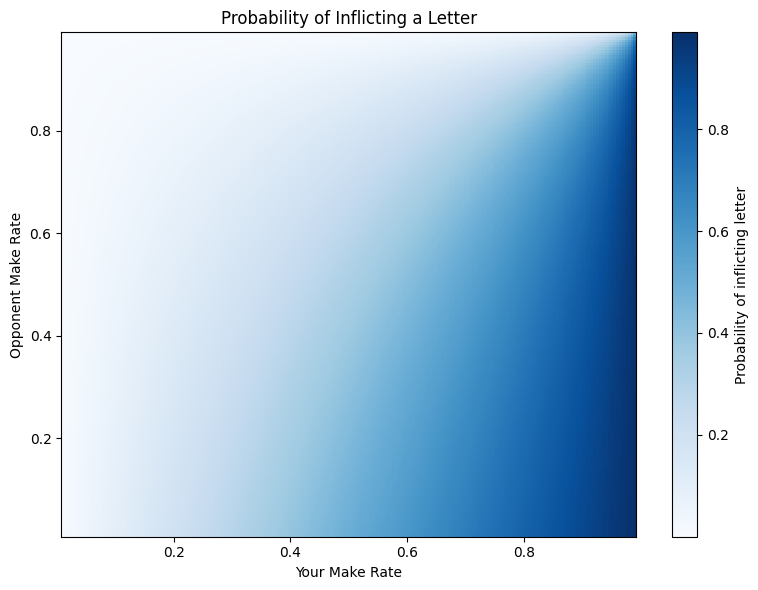

In [3]:
import matplotlib.pyplot as plt

plt.style.use("default")

# Visualize probability across the parameter space
plt.figure(figsize=(8, 6))
plt.pcolormesh(
    probability_df.columns, probability_df.index, probability_df,
     cmap='Blues'
)
plt.xlabel('Your Make Rate')
plt.ylabel('Opponent Make Rate')
plt.colorbar(label='Probability of inflicting letter')
plt.title('Probability of Inflicting a Letter')
plt.tight_layout()
plt.show()

Put simply, every possible shot corresponds to a point on this graph. The bluer the point, the more likely that shot is to eventually result in a letter for your opponent.

As expected, a shot becomes more effective when you are better at making it and your opponent is worse at making it. The make-it-take-it rules lead to an important additional insight: when your relative abilities are held constant, easier shots are generally preferable. There is no point at which a shot becomes "too easy" simply because you are good at it. If you make the shot, you retain your turn and get another opportunity to shoot; if you miss, your turn ends.

This creates an interesting tradeoff. A harder shot can still be preferable if you have a sufficiently large advantage over your opponent at that shot. In other words, the difficulty of a shot matters less than the combination of its difficulty and your relative advantage.

To explore this comparative advantage more intuitively, we'll use the ratio of the two players' odds of making a given shot. Odds ratios provide a useful way to compare relative shooting ability because they describe how much more likely one player is to make the shot than the other.

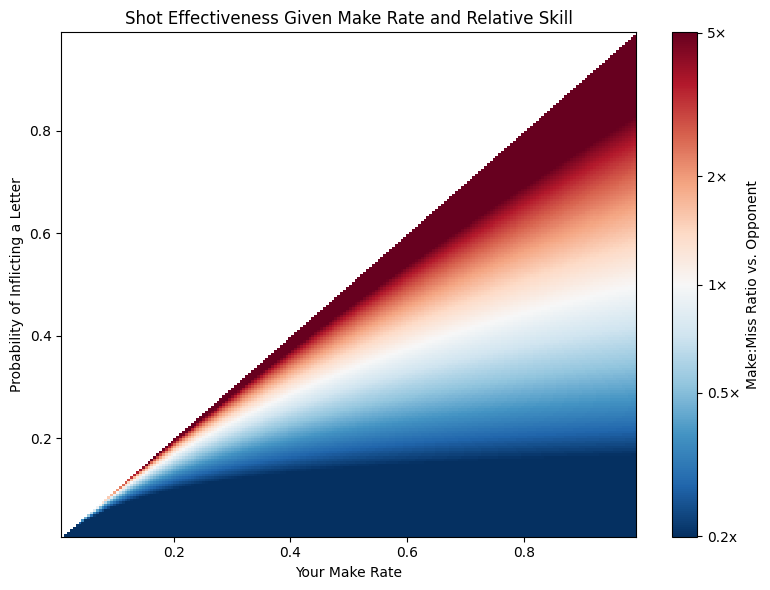

In [4]:
# Parameter grids
make_qs = np.linspace(0.01, 0.99, 200)
letter_qs = np.linspace(0.01, 0.99, 200)

x, y = np.meshgrid(make_qs, letter_qs)

# Required odds ratio:
with np.errstate(divide='ignore', invalid='ignore'):
    odds_ratio = (x * y) / (x - y)

# Impossible combinations: probability of giving a letter
# cannot exceed probability of making the initial shot
odds_ratio[y >= x] = np.nan

# Take log10 of odds ratio
log_odds_ratio = np.log10(odds_ratio)

# Plot
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    make_qs,
    letter_qs,
    log_odds_ratio,
    shading='auto',
    cmap='RdBu_r',
    vmin=-0.7,
    vmax= 0.7
)

plt.xlabel('Your Make Rate')
plt.ylabel('Probability of Inflicting a Letter')

cbar = plt.colorbar()
cbar.set_label('Make:Miss Ratio vs. Opponent')

# Make the tick labels more intuitive
cbar.set_ticks([np.log10(0.2), np.log10(0.5), 0, np.log10(2), np.log10(5)])
cbar.set_ticklabels(['0.2x','0.5×', '1×', '2×', '5×'])

plt.title('Shot Effectiveness Given Make Rate and Relative Skill')

plt.tight_layout()
plt.show()

Interestingly, comparative advantage matters more for easier shots than for harder ones. For example, suppose you and your opponent can both make an easy shot 18 out of 20 times. Because make-it-take-it rules allow the sequence to continue after both players make the shot, you will eventually inflict a letter about 47% of the time. If your own success rate increases to 19 out of 20 while your opponent remains at 18 out of 20, that probability rises to about 65.5%.

This simple model gives us a few takeaways to try in a game of HORSE:

1. Prefer shots that you are good at, especially when you have a substantial advantage over your opponent.
2. Practice your favorite high-percentage shots before the game.
3. Goad your opponent into choosing shots that are difficult for them.

## Model 2: Unknown Probabilities

In reality, we don't know the true probability that either we or our opponent will make a particular shot. Instead, we have to estimate these probabilities from the information available to us. Bayesian inference gives us a principled way to do this by representing our uncertainty about these quantities and updating our beliefs as we observe more data.

This section goes somewhat beyond what would be practical during an actual game of HORSE. The goal isn't to suggest that a player should perform a full Bayesian analysis before every shot, but to understand what an ideal decision-making process would look like when we account for uncertainty. Later, we'll use these results to develop a simpler strategy that captures the important insights without requiring all of the computational machinery.

Suppose you don't know your true probability of making a free throw, but you believe it is somewhere around 40%. We can represent this uncertainty with a Beta distribution. The Beta distribution is useful here because it is defined over the same range as a probability: from 0 to 1.

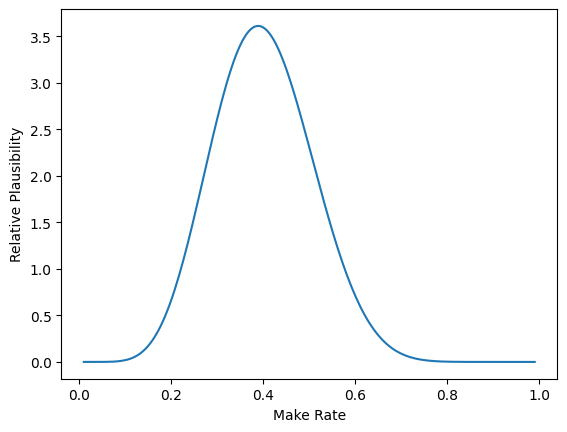

In [5]:
from scipy.stats import beta
from empiricaldist import Pmf

# Our current beliefs, roughly 8 makes for every 12 misses, represented as a beta distribution
alpha_param = 8
beta_param = 12
free_throw_ps = beta.pdf(make_qs, alpha_param, beta_param)

# A labeled distribution assigning each possible make_rate to its relative plausibility
free_throw_prior = Pmf(free_throw_ps, make_qs)

# Plot
plt.plot(free_throw_prior)
plt.xlabel('Make Rate')
plt.ylabel('Relative Plausibility')
plt.show()

We can update this distribution as we make or miss free throws. Each possible value of our true make rate becomes more or less plausible as we collect evidence. For example, a series of successful shots increases the probability assigned to higher make rates, while a series of misses shifts probability toward lower make rates.

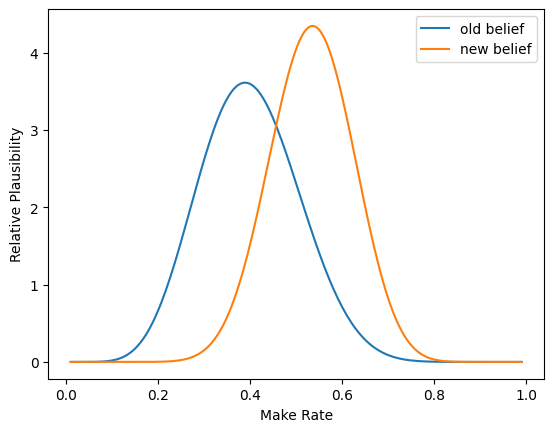

In [6]:
def update_beta(prior, data):
    """Return a new beta distribution given updated evidence"""
    makes, misses = data
    alpha_new = alpha_param + makes
    beta_new = beta_param + misses
    return Pmf(
        beta.pdf(prior.qs, alpha_new, beta_new),
        prior.qs
    )

# New evidence
makes = 8
misses = 2
data = (makes, misses)

# Update original distribution with new evidence
free_throw_updated = update_beta(free_throw_prior, data)

# Plot
plt.plot(free_throw_prior, label = 'old belief')
plt.plot(free_throw_updated, label = 'new belief')
plt.xlabel('Make Rate')
plt.ylabel('Relative Plausibility')
plt.legend()
plt.show()

We can do the same thing for our opponent. By observing their makes and misses, we can update our beliefs about their true ability. For this example, we'll assume that our opponent starts with the same prior distribution as we do, but that they subsequently perform poorly.

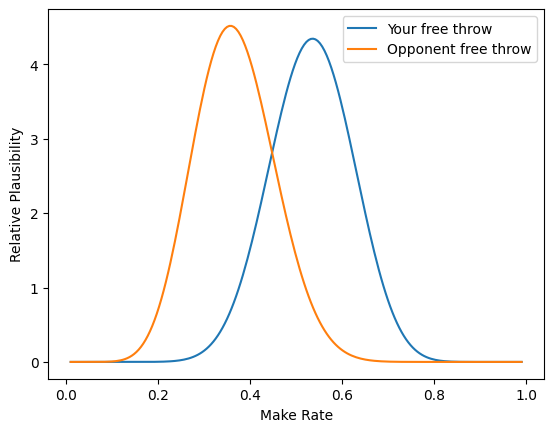

In [7]:
# Update with evidence: You make 8 and miss 4
free_throw = update_beta(free_throw_prior, (8,2))

# Update with evidence: Opponent makes 3 and misses 9
free_throw_opp = update_beta(free_throw_prior, (3,7))

#Plot
plt.plot(free_throw, label = 'Your free throw')
plt.plot(free_throw_opp, label = 'Opponent free throw')
plt.xlabel('Make Rate')
plt.ylabel('Relative Plausibility')
plt.legend()
plt.show()

We can plot the two distributions together in two dimensions to get a better picture of our uncertainty. Imagine placing our distribution and our opponent's distribution on perpendicular axes and looking at them from above.

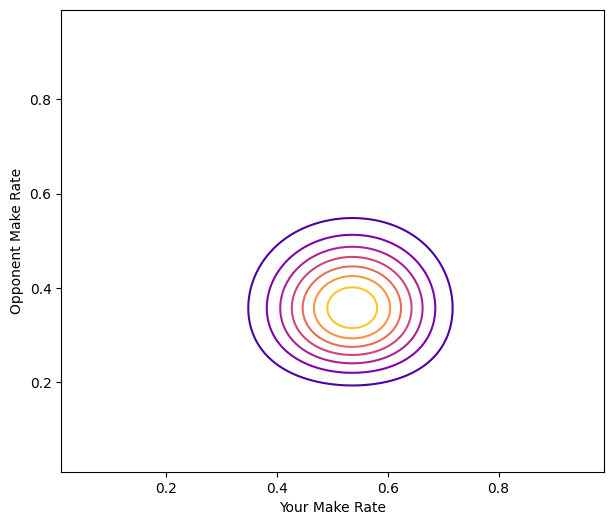

In [8]:
free_throw_pmf = Pmf(free_throw, make_qs)
free_throw_opp_pmf = Pmf(free_throw_opp, make_qs)

# Find the likelihood of each combination of free throw make rates
X,Y = np.meshgrid(free_throw.qs, free_throw_opp.qs)
data = np.outer(free_throw_opp.ps, free_throw.ps)

# Plot
plt.figure(figsize=(7, 6))
plt.contour(X, Y, data, cmap = 'plasma')
plt.xlabel('Your Make Rate')
plt.ylabel('Opponent Make Rate')
plt.show()

This represents our joint uncertainty about both players' true make rates.

Finally, we can overlay this distribution on the probability-of-inflicting-a-letter heatmap from the previous section. This lets us visualize how effective the shot might be while accounting for our uncertainty about both players' true abilities.

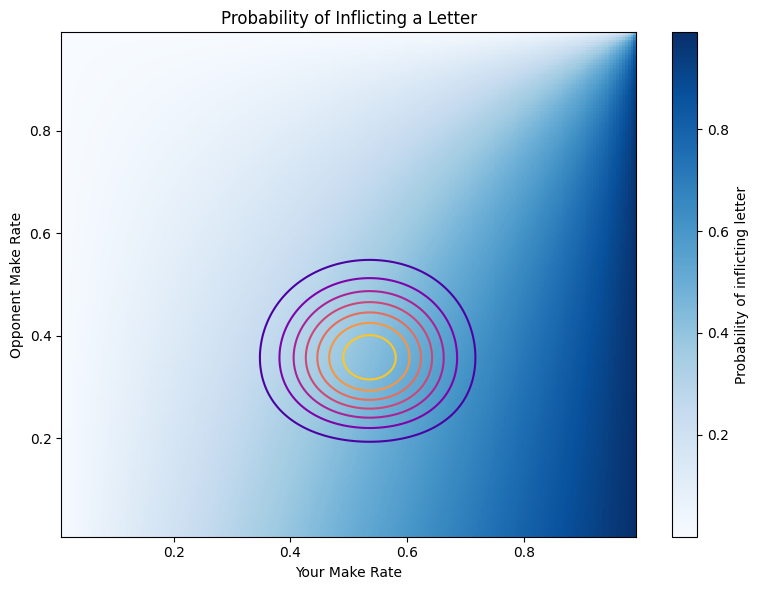

In [9]:
plt.figure(figsize=(8, 6))

# Show heatmap: probability of inflicting a letter
plt.pcolormesh(
    probability_df.columns, probability_df.index, probability_df,
     cmap='Blues'
)

plt.xlabel('Your Make Rate')
plt.ylabel('Opponent Make Rate')
plt.colorbar(label='Probability of inflicting letter')
plt.title('Probability of Inflicting a Letter')
plt.tight_layout()

# Overlay make rate distribution of free throws given our evidence
plt.contour(X, Y, data, cmap = 'plasma')

plt.show()

In other words, rather than assuming that we know the two make rates exactly, we are considering all of the possible combinations of abilities and weighting them according to how plausible they currently appear. The resulting distribution tells us how likely the shot is to inflict a letter given what we currently know.

Let's see what happens when we add some more shots to choose from. For the sake of example, we'll consider four different shots of increasing difficulty: layup, free throw, three-pointer, and hook shot. As before, we'll assume that we have some idea of our own ability to make each shot.

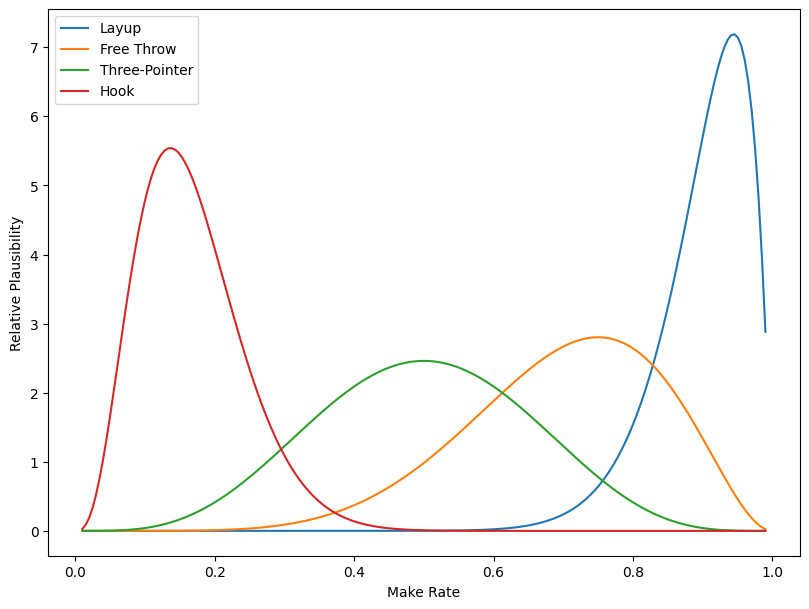

In [10]:
your_stats = {
    'Layup': {'makes': 18, 'misses': 2},
    'Free Throw': {'makes': 7, 'misses': 3},
    'Three-Pointer': {'makes': 5, 'misses': 5},
    'Hook': {'makes': 4, 'misses': 20}
}

def make_dist(stats):
    '''Make a probability distribution given make:miss evidence'''
    makes = stats['makes']
    misses = stats['misses']
    return Pmf(beta.pdf(make_qs, makes, misses), make_qs)


plt.figure(figsize=(8, 6))

# Plot each shot
for shot in your_stats.keys():
    plt.plot(make_dist(your_stats[shot]), label = shot)

plt.tight_layout()
plt.legend()
plt.xlabel('Make Rate')
plt.ylabel('Relative Plausibility')
plt.show()

We also don't know our opponent's true make rates. The most parsimonious assumption is that their abilities are similar to ours, but with greater uncertainty. This gives us a reasonable starting point without assuming that we know much about our opponent before the game begins.

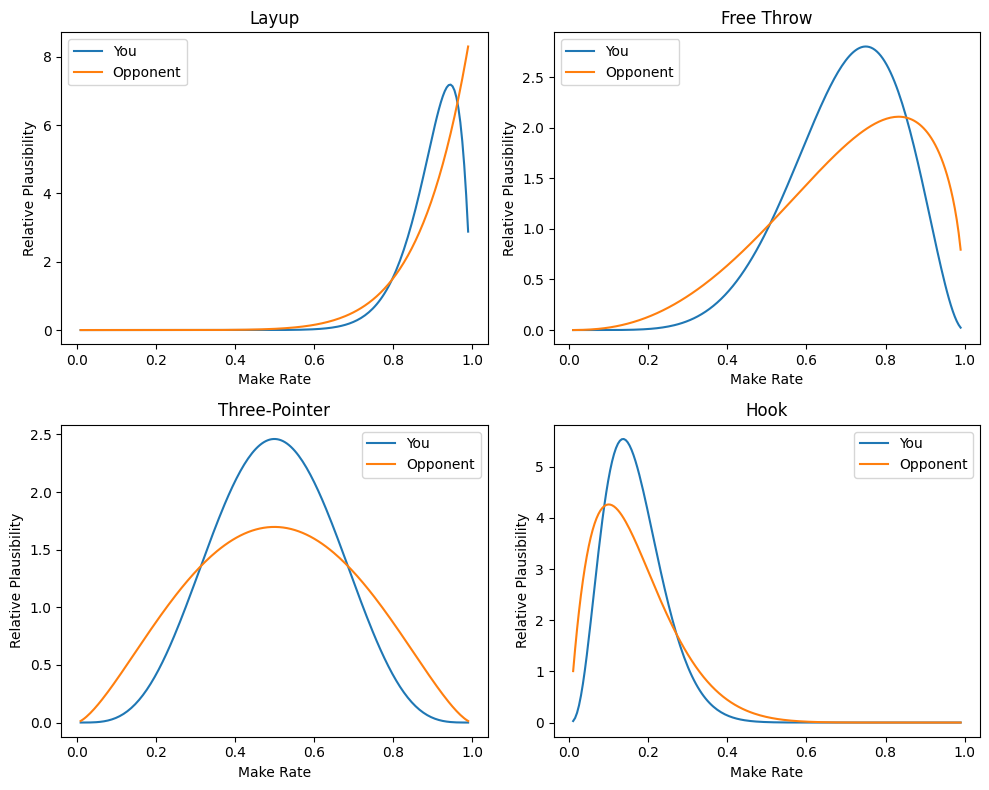

In [11]:
# Prior distributions of opponent's shots - Parameters are all the same as ours but cut in half to represent less certainty
opp_stats = {
    'Layup': {'makes': 9, 'misses': 1},
    'Free Throw': {'makes': 3.5, 'misses': 1.5},
    'Three-Pointer': {'makes': 2.5, 'misses': 2.5},
    'Hook': {'makes': 2, 'misses': 10}
}

stats = {'You': your_stats, 'Opponent': opp_stats}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Plot both distribution for each shot, each in a seperate box
for ax, shot in zip(axes.flat, your_stats):
    ax.plot(make_dist(your_stats[shot]), label = 'You')
    ax.plot(make_dist(opp_stats[shot]), label = 'Opponent')
    ax.set_title(shot)
    ax.set_xlabel('Make Rate')
    ax.set_ylabel('Relative Plausibility')
    ax.legend()

plt.tight_layout()
plt.show()

For each shot, we can compare the distributions representing our ability and our opponent's ability.

But what do these distributions mean in practical terms? The final conceptual step is to translate each pair of distributions into a more useful quantity: the probability that each shot will inflict a letter.

We'll represent this graphically as well.

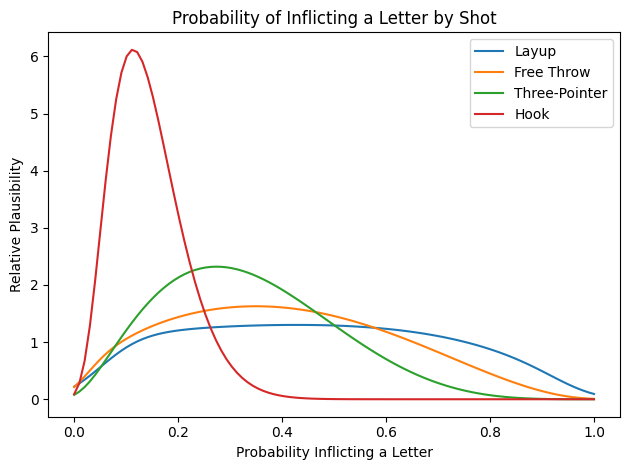

In [12]:
from scipy.stats import gaussian_kde

def plot_shot_effectiveness():
    for shot in stats['You'].keys():
        you = make_dist(stats['You'][shot])
        opp = make_dist(stats['Opponent'][shot])

        # Normalize probability so it sums to 1
        you_ps = you.ps / you.ps.sum()
        opp_ps = opp.ps / opp.ps.sum()

        # Find the probability of every combination of you vs. opponent make rate
        data = np.outer(you_ps, opp_ps)
        likelihoods = data.flatten()

        #weight probability of each combination by expected value of inflicting a letter
        probability_qs = np.linspace(0, 1, 100)
        game_value = probability_df.T.values.flatten()
        kde = gaussian_kde(
            game_value,
            weights=likelihoods)
        kde = kde(probability_qs)
        plt.plot(probability_qs, kde, label=shot)

    # plot outputs of function
    plt.title('Probability of Inflicting a Letter by Shot')
    plt.xlabel('Probability Inflicting a Letter')
    plt.ylabel('Relative Plausibility')
    plt.legend()
    plt.tight_layout()
    plt.show()

stats = {'You': your_stats, 'Opponent': opp_stats}
plot_shot_effectiveness()

To summarize, we've defined distributions representing our beliefs about our own and an unknown opponent's ability to make each of four shots. For every possible combination of these two probabilities, we've calculated the corresponding probability of eventually inflicting a letter. Combining these two pieces gives us a distribution for the probability that each shot will inflict a letter.

Conceptually, this is the same idea as the previous example, where we overlaid the two-dimensional distribution on the heatmap and considered how much of the distribution fell over high-probability regions.

Some shots appear more promising than others, but the distributions are wide enough that we cannot confidently identify a single "best" shot. For example, layups may currently have the highest expected probability of inflicting a letter, but there is still substantial uncertainty about whether free throws or three-pointers could ultimately be better.

Always choosing the shot with the highest current estimate would therefore risk overlooking a shot that we simply haven't learned enough about yet.

At the same time, exploration has a cost. Although it is technically possible that hook shots are the best option, our current beliefs make this unlikely. Spending a large amount of time testing them would therefore be inefficient when other shots have much more promising potential.

This creates the classic exploration-exploitation tradeoff. We want to exploit shots that currently appear effective, while still exploring shots that could plausibly turn out to be better. This is the fundamental problem addressed by multi-armed bandit algorithms.

We use Thompson sampling to balance these competing goals. In essence, we draw one possible value from the current distribution for each shot and choose the shot with the most favorable draw. Shots that are both promising and uncertain have a greater chance of being selected, while shots that are consistently unlikely to perform well are rarely chosen.

As we collect more data, the posterior distributions become narrower. The algorithm therefore becomes increasingly confident about which shots are effective and gradually shifts toward exploiting the shots supported by the evidence.

In [13]:
def choose_shot_Thompson():
    '''return the name of the shot chosen by Thompson sampling'''

    samples = {}
    for shot in stats['You']:

        you = make_dist(stats['You'][shot])
        opp = make_dist(stats['Opponent'][shot])

        # normalize distributions
        you_ps = you.ps / you.ps.sum()
        opp_ps = opp.ps / opp.ps.sum()

        # weight every combination of make rate by 1. its likelihood and 2. its game value
        likelihood = np.outer(you_ps, opp_ps).flatten()
        game_value = probability_df.T.values.flatten()

        # select a random point from this weighted distribution
        sample = np.random.choice(
            game_value,
            p=likelihood / likelihood.sum()
        )

        samples[shot] = sample

    #return the shot with the highest selected point
    return max(samples, key=samples.get)

print('Chosen shot: ' + choose_shot_Thompson())

Chosen shot: Free Throw


Using these functions, we're now close to simulating a complete game of HORSE. In this simulation, we will use Thompson sampling to select our shots while the opponent selects shots randomly.

In [14]:
from scipy.stats import binom
import random

def choose_shot_random():
    return random.choice(list(stats['You'].keys()))

def shoot(player, shot):
    """ Simulate shooting, and update stats accordingly """
    #random chance to make the shot, given true probs
    made = binom.rvs(1, true_probs[player][shot])
    #update stats based on random draw
    if made == 1:
        stats[player][shot]['makes'] +=1
    else:
        stats[player][shot]['misses'] +=1
    return made

def your_turn(shot):
    """ You shoot, and if you make it, opponent shoots """
    you_made = shoot('You', shot)
    if not you_made:
        return 'Opponent', 0 # you miss = opponents turn
    opp_made = shoot('Opponent', shot)
    if opp_made:
        return 'You', 0 # opponent make = your turn
    else:
        return 'You', 1 # opponent miss = your turn + opponent gains a letter

def opp_turn(shot):
    """ Opponent shoots, and if they make it, you shoot """
    opp_made = shoot('Opponent', shot)
    if not opp_made:
        return 'You', 0 # opponent miss = your turn
    you_made = shoot('You', shot)
    if you_made:
        return 'Opponent', 0 # you make = opponents turn
    else:
        return 'Opponent', 1 # you make = opponents turn + you gain a letter

def full_game(strategy, opp_strategy):
    """ Simulate a full game of HORSE """

    # These will be used later
    global consec_lose_turn
    consec_lose_turn = 0
    global shot_index
    shot_index = 0

    your_letters = 0
    opp_letters = 0
    turn = random.choice(['You', 'Opponent'])
    while (your_letters < 5) and (opp_letters < 5):
        if turn == 'You':
            turn, letter = your_turn(strategy())
            if letter:
                opp_letters += 1
            if turn == 'Opponent':
                consec_lose_turn += 1
            else:
                consec_lose_turn = 0
        else:
            turn, letter = opp_turn(opp_strategy())
            if letter:
                your_letters += 1
    if your_letters == 5:
        return 0
    return 1

def set_stats(layup, freethrow, threepointer, hook, layup_opp, freethrow_opp, threepointer_opp, hook_opp):
    """ Set a dictionary of stats (make:miss tuples) to reflect beliefs before game """
    global stats
    stats = {
            'You':
                {
                'Layup': {'makes': layup[0], 'misses': layup[1]},
                'Free Throw': {'makes': freethrow[0], 'misses': freethrow[1]},
                'Three-Pointer': {'makes': threepointer[0], 'misses': threepointer[1]},
                'Hook': {'makes': hook[0], 'misses': hook[1]}
                },

            'Opponent':
                {
                'Layup': {'makes': layup_opp[0], 'misses': layup_opp[1]},
                'Free Throw': {'makes': freethrow_opp[0], 'misses': freethrow_opp[1]},
                'Three-Pointer': {'makes': threepointer_opp[0], 'misses': threepointer_opp[1]},
                'Hook': {'makes': hook_opp[0], 'misses': hook_opp[1]}
                }
            }

def set_true_probs(layup, freethrow, threepointer, hook, layup_opp, freethrow_opp, threepointer_opp, hook_opp):
    """ Set the actual probability of making a shot before a game (our model doesn't know this value) """
    global true_probs

    true_probs = {
    'You': {'Layup': layup, 'Free Throw': freethrow, 'Three-Pointer': threepointer, 'Hook': hook},
    'Opponent': {'Layup': layup_opp, 'Free Throw': freethrow_opp, 'Three-Pointer': threepointer_opp, 'Hook': hook_opp}
    }

We can now simulate the results of multiple games pitting Thompson sampling against random shot selection.

631 wins out of 1000


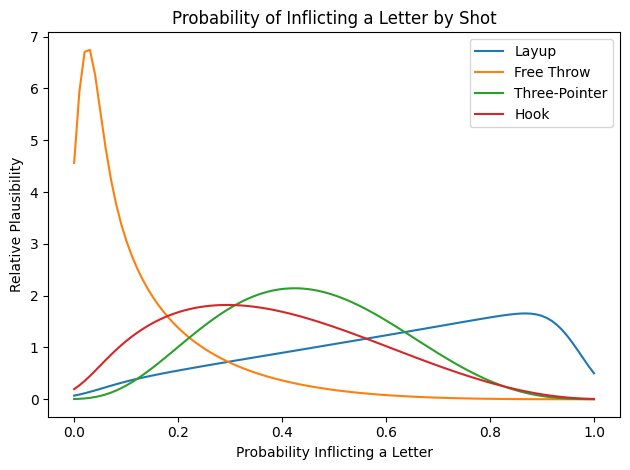

{'You': {'Layup': 0.84, 'Free Throw': 0.23, 'Three-Pointer': 0.47, 'Hook': 0.39}, 'Opponent': {'Layup': 0.8, 'Free Throw': 0.54, 'Three-Pointer': 0.38, 'Hook': 0.18}}


In [15]:
wins = 0
trials = 1000

for i in range(trials):

    # Reset prior beliefs - make them only vaguely informative
    set_stats((4,1),(2,1),(1,1),(1,2),(2,0.5),(1,0.5),(0.5,0.5),(0.5,1))

    # Randomly assign true make rates for each game,
    set_true_probs(round(np.random.beta(12, 3), 2), round(np.random.beta(6, 3), 2), round(np.random.beta(3,3), 2), round(np.random.beta(3,6), 2), round(np.random.beta(12,3), 2), round(np.random.beta(6,3),2), round(np.random.beta(3,3),2), round(np.random.beta(3,6), 2))

    # Simulate a game where you select with Thompson and opponent selects randomly
    wins+=full_game(strategy = choose_shot_Thompson, opp_strategy = choose_shot_random)


# Display win rate for this simulation
print(str(wins) + ' wins out of ' + str(trials))

# Plot your updated beliefs about each shot's effectiveness for the last simulated game.
plot_shot_effectiveness()

# Display you vs. your opponent's true make rate for the last simulated game
print(true_probs)

Repeating the simulation above, we win about 6 of 10 in the long run.

To summarize our model so far now: we maintain a joint posterior over our own and our opponent's make probabilities. Because the probability of inflicting a letter is a deterministic function of those two probabilities, this induces a posterior distribution over the value of the shot itself. Thompson sampling draws one plausible value for each shot and selects the shot with the highest draw.

The current assumptions are relatively conservative:

1. We and the opponent are relatively evenly matched.
2. Our skills come from the same, somewhat predictable distribution.
3. We begin with only a vague idea of the make rates for each shot.

These assumptions give Thompson sampling a meaningful but imperfect advantage. In the next section, we'll see what happens when we change them.

## Sensitivity, Robustness, and Computational Efficiency

So far, Thompson sampling has performed well under the assumptions of our model. However, the Bayesian strategy requires substantially more computation and information than a player could realistically use during an actual game.

In this section, we'll introduce a simpler strategy that captures some of the key insights from our model while being simple enough to use in a real game. We'll then stress-test and compare our strategies under a range of different assumptions to see how robust they are to changing conditions.

The goal is not simply to find a strategy that performs well under one particular set of assumptions. Instead, we want to understand how sensitive our conclusions are to the assumptions built into the model, and whether the additional complexity of the Bayesian approach provides a meaningful advantage.

To capture the most important benefits of the more complex strategy, our simplified strategy should be based on two principles:

Favor easier shots, since easier shots are generally more likely to inflict a letter.
Exploit advantages by selecting shots where our estimated ability provides a meaningful advantage over our opponent.

Importantly, the strategy should do this without requiring the player to memorize specific make rates or perform complicated calculations during the game.

The strategy below is a simple approximation of these principles.

In [16]:
def choose_shot_simplified():
    """Choose the shot that is generally the easiest, then try a harder one if fail to inflict a letter two turns in a row, and so forth"""
    global shot_index
    global consec_lose_turn
    if consec_lose_turn >= 2:
        if (shot_index < len(list(stats['You'].keys())) - 1):
            shot_index +=1
        else:
            shot_index = 0
        consec_lose_turn = 0
    return list(stats['You'].keys())[shot_index]

Let's simulate multiple games of this strategy against random shot selection.

In [17]:
wins_complex = 0
wins_simple = 0
trials = 1000

for i in range(trials):

    # ...reset prior beliefs - make them only vaguely informative
    set_stats((4,1),(2,1),(1,1),(1,2),(2,0.5),(1,0.5),(0.5,0.5),(0.5,1))

    # ...randomly assign true make rates
    set_true_probs(round(np.random.beta(12, 3), 2), round(np.random.beta(6, 3), 2), round(np.random.beta(3,3), 2), round(np.random.beta(3,6), 2), round(np.random.beta(12,3), 2), round(np.random.beta(6,3),2), round(np.random.beta(3,3),2), round(np.random.beta(3,6), 2))

    # Simulate a game with each strategy, given the same circumstances
    wins_complex += full_game(strategy = choose_shot_Thompson, opp_strategy = choose_shot_random)
    set_stats((4,1),(2,1),(1,1),(1,2),(2,0.5),(1,0.5),(0.5,0.5),(0.5,1))
    wins_simple += full_game(strategy = choose_shot_simplified, opp_strategy = choose_shot_random)

# Display win rate for this simulation
print('Complex strategy: ' + str(wins_complex) + ' wins out of ' + str(trials))
print('Simple strategy: ' + str(wins_simple) + ' wins out of ' + str(trials))

Complex strategy: 635 wins out of 1000
Simple strategy: 693 wins out of 1000


The simplified strategy actually performs slightly better than Thompson sampling in this setting, winning about two-thirds of games against a randomly selecting opponent.

One possible explanation is that the simplified strategy places more emphasis on exploitation, while Thompson sampling deliberately spends some of its time exploring uncertain shots. HORSE is a relatively short game, so there may not be enough time for the long-term benefits of exploration to outweigh its immediate cost.

If we instead played multiple games against the same opponents while keeping information between games, we would expect Thompson sampling to benefit from having more opportunities to learn. Over time, information gained through exploration could be reused rather than discarded at the end of each game.

Let's see if this prediction holds. We'll compare the two strategies when we play against 10 opponents, playing 10 games against each opponent while retaining information between games.

In [18]:
wins_complex = 0
wins_simple = 0
trials = 1000

for i in range(trials):

    if i % 10 == 0: # Every 10 games...
        # ...reset prior beliefs - make them only vaguely informative
        set_stats((4,1),(2,1),(1,1),(1,2),(2,0.5),(1,0.5),(0.5,0.5),(0.5,1))

        # ...randomly assign true make rates
        set_true_probs(round(np.random.beta(12, 3), 2), round(np.random.beta(6, 3), 2), round(np.random.beta(3,3), 2), round(np.random.beta(3,6), 2), round(np.random.beta(12,3), 2), round(np.random.beta(6,3),2), round(np.random.beta(3,3),2), round(np.random.beta(3,6), 2))

    # Simulate a game with each strategy, given the same circumstances
    wins_complex += full_game(strategy = choose_shot_Thompson, opp_strategy = choose_shot_random)
    set_stats((4,1),(2,1),(1,1),(1,2),(2,0.5),(1,0.5),(0.5,0.5),(0.5,1))
    wins_simple += full_game(strategy = choose_shot_simplified, opp_strategy = choose_shot_random)

# Display win rate for this simulation
print('Complex strategy: ' + str(wins_complex) + ' wins out of ' + str(trials))
print('Simple strategy: ' + str(wins_simple) + ' wins out of ' + str(trials))

Complex strategy: 638 wins out of 1000
Simple strategy: 637 wins out of 1000


Indeed, the complex strategy is superior when information is retained between games. This suggests that the value of Thompson sampling depends not only on the quality of its decisions, but also on how many opportunities it has to learn from its exploration.

Another assumption built into the complex model is the information contained in the prior distributions. Our results could potentially depend on how accurately these priors represent the true distribution of shooting ability.

Let's see how the win rate changes when we make the prior beliefs highly informative, so that they closely match the underlying distribution from which the true make rates are generated.

Here's what the prior beliefs look like now.

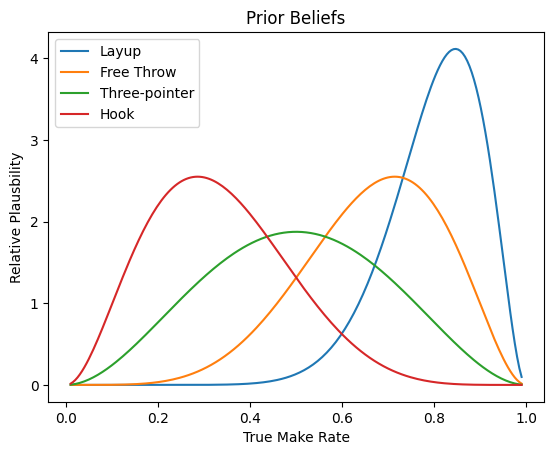

In [19]:
# Set informative prior beliefs equal to underlying distributions
set_stats((12,3),(6,3),(3,3),(3,6),(12, 3),(6,3),(3,3),(3,6))

# Plot prior beliefs (which are now the same as underlying distributions)
plt.plot(Pmf(beta.pdf(make_qs,12,3), make_qs), label = 'Layup')
plt.plot(Pmf(beta.pdf(make_qs,6,3), make_qs), label = 'Free Throw')
plt.plot(Pmf(beta.pdf(make_qs,3,3), make_qs), label = 'Three-pointer')
plt.plot(Pmf(beta.pdf(make_qs,3,6), make_qs), label = 'Hook')
plt.legend()
plt.title('Prior Beliefs')
plt.ylabel('Relative Plausbility')
plt.xlabel('True Make Rate')
plt.show()

In the graph above, each line represents the prior belief about the make rate for a given shot. The priors for you and your opponent are identical for each shot. We'll now simulate games starting from these highly informative prior beliefs.

In [20]:
wins_complex = 0
trials = 1000

for i in range(trials):

    # ...reset prior beliefs - make them informative
    set_stats((12,3),(6,3),(3,3),(3,6),(12, 3),(6,3),(3,3),(3,6))
    # ...randomly assign true make rates
    set_true_probs(round(np.random.beta(12, 3), 2), round(np.random.beta(6, 3), 2), round(np.random.beta(3,3), 2), round(np.random.beta(3,6), 2), round(np.random.beta(12,3), 2), round(np.random.beta(6,3),2), round(np.random.beta(3,3),2), round(np.random.beta(3,6), 2))

    # Simulate a game with each strategy, given the same circumstances
    wins_complex += full_game(strategy = choose_shot_Thompson, opp_strategy = choose_shot_random)

# Display win rate for this simulation
print('Complex strategy: ' + str(wins_complex) + ' wins out of ' + str(trials))

Complex strategy: 608 wins out of 1000


Even with this additional information, the win rate changes relatively little.

Now let's consider the opposite extreme. We'll make the prior beliefs completely uninformative, so that before each game, almost any make rate is considered plausible for every shot.

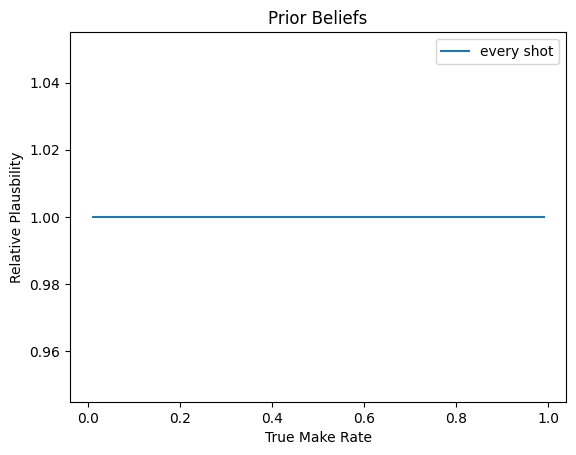

In [21]:
# Plot uninformative (overlapping) prior beliefs.
set_stats((1,1),(1,1),(1,1),(1,1),(1,1),(1,1),(1,1),(1,1))

plt.plot(Pmf(beta.pdf(make_qs,1,1), make_qs), label = 'every shot')
plt.legend()
plt.title('Prior Beliefs')
plt.ylabel('Relative Plausbility')
plt.xlabel('True Make Rate')
plt.show()

For clarity, this means that both you and your opponent begin each game with very little information about your respective make rates. Let's see how this severe lack of prior knowledge affects the win rate.

In [22]:
wins_complex = 0
trials = 1000

for i in range(trials):

    # ...reset prior beliefs - make them uninformative
    set_stats((1,1),(1,1),(1,1),(1,1),(1,1),(1,1),(1,1),(1,1))
    # ...randomly assign true make rates
    set_true_probs(round(np.random.beta(12, 3), 2), round(np.random.beta(6, 3), 2), round(np.random.beta(3,3), 2), round(np.random.beta(3,6), 2), round(np.random.beta(12,3), 2), round(np.random.beta(6,3),2), round(np.random.beta(3,3),2), round(np.random.beta(3,6), 2))

    # Simulate a game with each strategy, given the same circumstances
    wins_complex += full_game(strategy = choose_shot_Thompson, opp_strategy = choose_shot_random)

# Display win rate for this simulation
print('Complex strategy: ' + str(wins_complex) + ' wins out of ' + str(trials))

Complex strategy: 598 wins out of 1000


Once again, the win rate changes very little.

This suggests that the exact choice of prior has only a modest effect on the performance of our complex strategy in this setting. This is encouraging, because it means that the strategy does not appear to depend heavily on having unusually accurate prior beliefs.

Finally, we'll examine what happens when we change the underlying distribution of shooting ability. Rather than changing what we believe about the players, we'll change the actual make rates from which the games are generated.

We'll vary two major characteristics of this distribution:

The mean: whether we are generally better or worse than our opponent.
The variation: whether players' abilities differ substantially across shots or are more similar.

First, what happens when our expected make rate is higher than our opponent's for each shot? We'll increase our expected make:miss ratio by 50% and decrease the opponent's by 50%

In [23]:
wins_complex = 0
wins_simple = 0
wins_random = 0
trials = 1000

for i in range(trials):

    # Reset prior beliefs - make them only vaguely informative
    set_stats((4,1),(2,1),(1,1),(1,2),(2,0.5),(1,0.5),(0.5,0.5),(0.5,1))

    # Increase expected make:miss by 50% for player, decrease by 50% for opponent
    set_true_probs(round(np.random.beta(14.4, 2.4), 2), round(np.random.beta(7.2, 2.4), 2), round(np.random.beta(3.6,2.4), 2), round(np.random.beta(3.6,4.8), 2), round(np.random.beta(9.6,3.6), 2), round(np.random.beta(4.8,3.6),2), round(np.random.beta(2.4,3.6),2), round(np.random.beta(2.4,7.2), 2))

    # Simulate a game with each strategy, given the same circumstances
    wins_complex += full_game(strategy = choose_shot_Thompson, opp_strategy = choose_shot_random)
    set_stats((4,1),(2,1),(1,1),(1,2),(2,0.5),(1,0.5),(0.5,0.5),(0.5,1))
    wins_simple += full_game(strategy = choose_shot_simplified, opp_strategy = choose_shot_random)
    set_stats((4,1),(2,1),(1,1),(1,2),(2,0.5),(1,0.5),(0.5,0.5),(0.5,1))
    wins_random += full_game(strategy = choose_shot_random, opp_strategy = choose_shot_random)

win_lose_random = round(wins_random / (trials - wins_random), 2)
win_lose_complex = round(wins_complex / (trials - wins_complex), 2)
complex_improvement = round(((100*win_lose_complex / win_lose_random) - 100),0)
win_lose_simple = round(wins_simple / (trials - wins_simple), 2)
simple_improvement = round(((100*win_lose_simple / win_lose_random) - 100),0)

# Display win rate for this simulation
print('Random strategy: ' + str(wins_random) + ' wins out of ' + str(trials) + '\nwin/lose ratio = ' + str(win_lose_random)+'\n')
print('Complex strategy: ' + str(wins_complex) + ' wins out of ' + str(trials) + '\nwin/lose ratio = ' + str(win_lose_complex) + ' (' + str(complex_improvement)+ '% improvement)\n')
print('Simple strategy: ' + str(wins_simple) + ' wins out of ' + str(trials) + '\nwin/lose ratio = ' + str(win_lose_simple) + ' (' + str(simple_improvement)+ '% improvement)')

Random strategy: 860 wins out of 1000
win/lose ratio = 6.14

Complex strategy: 940 wins out of 1000
win/lose ratio = 15.67 (155.0% improvement)

Simple strategy: 950 wins out of 1000
win/lose ratio = 19.0 (209.0% improvement)


What if the opponent's make rate is 50% higher than yours on average?

In [24]:
wins_complex = 0
wins_simple = 0
wins_random = 0
trials = 1000

for i in range(trials):

    # ...reset prior beliefs - make them only vaguely informative
    set_stats((4,1),(2,1),(1,1),(1,2),(2,0.5),(1,0.5),(0.5,0.5),(0.5,1))

    # Increase expected make:miss by 50% for opponent, decrease by 50% for player
    set_true_probs(round(np.random.beta(9.6,3.6), 2), round(np.random.beta(4.8,3.6),2), round(np.random.beta(2.4,3.6),2), round(np.random.beta(2.4,7.2), 2), round(np.random.beta(14.4, 2.4), 2), round(np.random.beta(7.2, 2.4), 2), round(np.random.beta(3.6,2.4), 2), round(np.random.beta(3.6,4.8), 2))

    # Simulate a game with each strategy, given the same circumstances
    wins_complex += full_game(strategy = choose_shot_Thompson, opp_strategy = choose_shot_random)
    set_stats((4,1),(2,1),(1,1),(1,2),(2,0.5),(1,0.5),(0.5,0.5),(0.5,1))
    wins_simple += full_game(strategy = choose_shot_simplified, opp_strategy = choose_shot_random)
    set_stats((4,1),(2,1),(1,1),(1,2),(2,0.5),(1,0.5),(0.5,0.5),(0.5,1))
    wins_random += full_game(strategy = choose_shot_random, opp_strategy = choose_shot_random)


win_lose_random = round(wins_random / (trials - wins_random), 2)
win_lose_complex = round(wins_complex / (trials - wins_complex), 2)
complex_improvement = round(((100*win_lose_complex / win_lose_random) - 100),0)
win_lose_simple = round(wins_simple / (trials - wins_simple), 2)
simple_improvement = round(((100*win_lose_simple / win_lose_random) - 100),0)

# Display win rate for this simulation
print('Random strategy: ' + str(wins_random) + ' wins out of ' + str(trials) + '\nwin/lose ratio = ' + str(win_lose_random)+'\n')
print('Complex strategy: ' + str(wins_complex) + ' wins out of ' + str(trials) + '\nwin/lose ratio = ' + str(win_lose_complex) + ' (' + str(complex_improvement)+ '% improvement)\n')
print('Simple strategy: ' + str(wins_simple) + ' wins out of ' + str(trials) + '\nwin/lose ratio = ' + str(win_lose_simple) + ' (' + str(simple_improvement)+ '% improvement)')


Random strategy: 146 wins out of 1000
win/lose ratio = 0.17

Complex strategy: 238 wins out of 1000
win/lose ratio = 0.31 (82.0% improvement)

Simple strategy: 261 wins out of 1000
win/lose ratio = 0.35 (106.0% improvement)


Across both extremes, the relative performance of the three strategies remains remarkably stable. Both strategies generally improve upon the random strategy's win rate significantly, with the simple strategy being favored overall.

In the final test of our models, we'll examine what happens when there is more or less variation in the make rates of different shots.

Before running the simulation, we would expect greater variation to favor the complex strategy. Greater variation makes it more likely that a particular shot will produce a large skill gap between the players. For example, if we are able to make a hook shot 70% of the time while our opponent makes it only 9% of the time, a strategy capable of identifying and exploiting that difference should have a substantial advantage.

By multiplying/dividing both the alpha and the beta parameters by the same number, the mean is preserved, while changing the concentration of the distribution.

Let's start by adding more variation by dividing all parameters by 3.

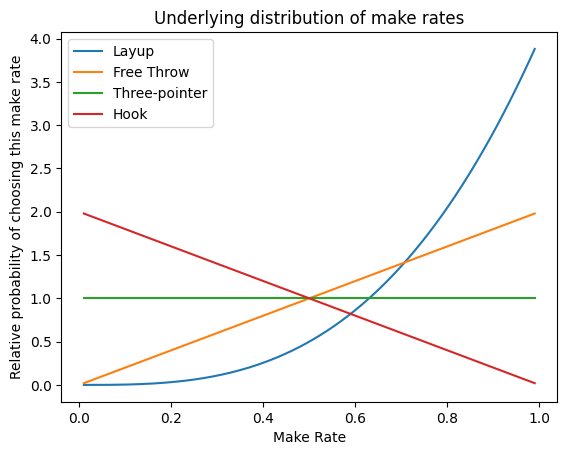

In [25]:
# Add more variation to underlying distributions of make rates (divide all parameters by 3)
set_true_probs(round(np.random.beta(4, 1), 2), round(np.random.beta(2, 1), 2), round(np.random.beta(1,1), 2), round(np.random.beta(1,2), 2), round(np.random.beta(4, 1), 2), round(np.random.beta(2, 1), 2), round(np.random.beta(1,1), 2), round(np.random.beta(1,2), 2))

# Plot the new underlying distributions of make rates
plt.plot(Pmf(beta.pdf(make_qs,4,1), make_qs), label = 'Layup')
plt.plot(Pmf(beta.pdf(make_qs,2,1), make_qs), label = 'Free Throw')
plt.plot(Pmf(beta.pdf(make_qs,1,1), make_qs), label = 'Three-pointer')
plt.plot(Pmf(beta.pdf(make_qs,1,2), make_qs), label = 'Hook')
plt.legend()
plt.title('Underlying distribution of make rates')
plt.ylabel('Relative probability of choosing this make rate')
plt.xlabel('Make Rate')
plt.show()

In [26]:
wins_complex = 0
wins_simple = 0
trials = 1000

for i in range(trials):

    # ...reset prior beliefs - make them only vaguely informative
    set_stats((4,1),(2,1),(1,1),(1,2),(2,0.5),(1,0.5),(0.5,0.5),(0.5,1))

    # ...randomly assign true make rates - with extra variation
    set_true_probs(round(np.random.beta(4, 1), 2), round(np.random.beta(2, 1), 2), round(np.random.beta(1,1), 2), round(np.random.beta(1,2), 2), round(np.random.beta(4, 1), 2), round(np.random.beta(2, 1), 2), round(np.random.beta(1,1), 2), round(np.random.beta(1,2), 2))

    # Simulate a game with each strategy, given the same circumstances
    wins_complex += full_game(strategy = choose_shot_Thompson, opp_strategy = choose_shot_random)
    set_stats((4,1),(2,1),(1,1),(1,2),(2,0.5),(1,0.5),(0.5,0.5),(0.5,1))
    wins_simple += full_game(strategy = choose_shot_simplified, opp_strategy = choose_shot_random)

# Display win rate for this simulation
print('Complex strategy: ' + str(wins_complex) + ' wins out of ' + str(trials))
print('Simple strategy: ' + str(wins_simple) + ' wins out of ' + str(trials))

Complex strategy: 679 wins out of 1000
Simple strategy: 688 wins out of 1000


With this additional variation in skill, the complex strategy is more effective than before, but only enough to perform approximately as well as the simple strategy.

It's reasonable to expect the opposite when we reduce the variation in make rates: if there are fewer large differences in ability to discover, there should be less benefit from a strategy designed to learn and exploit them. Let's see what happens.

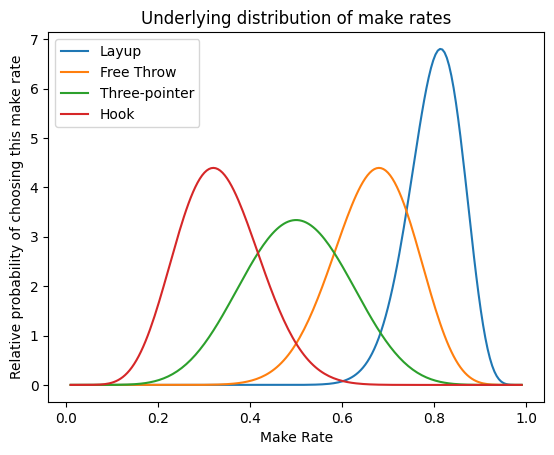

In [27]:
# Reduce variation from the underlying make rates (multiply all parameters by 3)
set_true_probs(round(np.random.beta(36, 9), 2), round(np.random.beta(18, 9), 2), round(np.random.beta(9,9), 2), round(np.random.beta(9,18), 2), round(np.random.beta(36, 9), 2), round(np.random.beta(18, 9), 2), round(np.random.beta(9,9), 2), round(np.random.beta(9,18), 2))

# Plot the new underlying distributions of make rates
plt.plot(Pmf(beta.pdf(make_qs,36,9), make_qs), label = 'Layup')
plt.plot(Pmf(beta.pdf(make_qs,18,9), make_qs), label = 'Free Throw')
plt.plot(Pmf(beta.pdf(make_qs,9,9), make_qs), label = 'Three-pointer')
plt.plot(Pmf(beta.pdf(make_qs,9,18), make_qs), label = 'Hook')
plt.legend()
plt.title('Underlying distribution of make rates')
plt.ylabel('Relative probability of choosing this make rate')
plt.xlabel('Make Rate')
plt.show()

In [28]:
wins_complex = 0
wins_simple = 0
trials = 1000

for i in range(trials):

    # ...reset prior beliefs - make them only vaguely informative
    set_stats((4,1),(2,1),(1,1),(1,2),(2,0.5),(1,0.5),(0.5,0.5),(0.5,1))

    # ...randomly assign true make rates - with reduced variation
    set_true_probs(round(np.random.beta(36, 9), 2), round(np.random.beta(18, 9), 2), round(np.random.beta(9,9), 2), round(np.random.beta(9,18), 2), round(np.random.beta(36, 9), 2), round(np.random.beta(18, 9), 2), round(np.random.beta(9,9), 2), round(np.random.beta(9,18), 2))

    # Simulate a game with each strategy, given the same circumstances
    wins_complex += full_game(strategy = choose_shot_Thompson, opp_strategy = choose_shot_random)
    set_stats((4,1),(2,1),(1,1),(1,2),(2,0.5),(1,0.5),(0.5,0.5),(0.5,1))
    wins_simple += full_game(strategy = choose_shot_simplified, opp_strategy = choose_shot_random)

# Display win rate for this simulation
print('Complex strategy: ' + str(wins_complex) + ' wins out of ' + str(trials))
print('Simple strategy: ' + str(wins_simple) + ' wins out of ' + str(trials))

Complex strategy: 594 wins out of 1000
Simple strategy: 627 wins out of 1000


All in all, both the complex and simple strategies are robust across the tested range of assumptions. Across the scenarios examined, both informed strategies consistently outperformed random shot selection.

This advantage persists whether or not information is retained between games and whether we are generally better or worse than our opponent. It also persists across different levels of heterogeneity in make rates across shots.

However, certain conditions do tend to favor one strategy over the other. More specifically:
- The more information that can be retained between games, the better the complex strategy performs.
- The greater the heterogeneity in make rates across different shots, the more the complex strategy benefits from its ability to explore and learn.

Finally, although the complex strategy relies on prior distributions, its performance appears to be relatively robust to the choice of prior beliefs. This suggests that the strategy's advantage is driven more by its ability to update and use information than by the precise assumptions encoded in its initial priors.

## Conclusions


This project developed a Bayesian approach to shot selection in HORSE and compared it with simpler strategies under a range of conditions.

The central tension that this model attempts to resolve is that difficulty and relative advantage both matter, but neither alone determines the optimal shot. Instead, the most valuable shots are those where we are both likely to succeed and have a meaningful advantage over our opponent. When these probabilities are unknown, Bayesian inference provides a way to learn about them as the game progresses.

Thompson sampling provides one way to turn this uncertainty into a practical decision rule by balancing exploration and exploitation. In short games, however, a much simpler strategy can perform comparably well, particularly when information cannot be carried from one game to the next. When information can be accumulated across multiple games, the additional exploration performed by Thompson sampling becomes more valuable.

Most importantly, the advantage of informed shot selection remained fairly robust across the assumptions we tested. Both the complex and simple strategies consistently outperformed random selection, while the relative performance of the two informed strategies depended on how much information was available and how heterogeneous the make rates across shots were.

These results suggest that sophisticated Bayesian decision-making can provide useful insights even when the full model is too computationally demanding for practical use. The simpler strategy captures much of that benefit while requiring far less information and computation, illustrating an important tradeoff between theoretical optimality, computational complexity, and practical usability.

## Model Limitations and Future Work

This model is only applicable to the rules and shot selection specified above: a one-versus-one matchup using make-it-take-it rules and a predefined set of shots. The optimal shot selection strategy may differ in games with more players, different rules, or a different set of available shots.

The model also assumes that each player's probability of making a given shot is stable throughout a game. In reality, shooting performance may vary due to factors such as fatigue, pressure, confidence, or temporary changes in performance (e.g., a "hot streak"). If a player's underlying ability changes over time, observations from earlier in the game may no longer accurately represent their current ability, causing the posterior distribution to become overly confident. A more realistic model could allow shooting ability to evolve dynamically throughout a game. This shot-to-shot variation within a game would pose an additional challenge to the Bayesian model, forcing it consider the plausibility not just of each shooting percentage hypothesis, but rather each combination of parameters for a curve (e.g. every combination of alpha and beta in a beta distribution). This would add an additional dimension to each calculation, potentially requiring another method besides discrete approximation.

Additionally, we compare the Bayesian strategy to a baseline of random shot selection. In an actual game, however, an opponent would likely use a more informed strategy based on their own strengths and weaknesses and their knowledge of the player's weaknesses. Modeling the opponent as a strategic, adaptive player would provide a more realistic comparison and could substantially change the relative performance of different strategies.

The model also optimizes the probability of inflicting a letter on the opponent rather than directly optimizing the probability of winning the entire game. For a one-versus-one matchup under the rules specified above, these objectives largely lead to the same shot selection decision: a higher probability of inflicting a letter on the opponent directly increases the probability that the opponent receives the next letter, while the alternative outcome gives the player another opportunity to shoot. This equivalence does not necessarily hold under different game structures, such as games involving more than two players.

Finally, the model assumes that the probability of making a given shot follows a Beta distribution. While the Beta distribution is convenient because it is defined on the interval [0, 1] and is conjugate to the Bernoulli likelihood, the choice of prior distribution can influence the model's representation of extreme shooting abilities. In particular, a simple Beta distribution may assign more probability to extremely high shooting percentages than would be realistic for some types of shots. A more realistic model could use empirical shooting data to estimate the distribution of player abilities, or use a hierarchical model that allows the distribution of shooting ability to vary across shot types.

These limitations do not necessarily invalidate the model's conclusions, but they define the assumptions under which those conclusions should be interpreted. Future work could therefore examine whether the results remain robust when these assumptions are relaxed, particularly by varying the assumed distribution of player ability, incorporating strategic opponents, and allowing shooting ability to change over time.